In [1]:
%matplotlib inline

import math

import torch
from d2l import torch as d2l

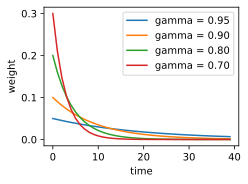

In [2]:
# RMSProp의 과거 Gradient Weight

d2l.set_figsize()

gammas = (
    0.95,
    0.9,
    0.8,
    0.7,
)

# 현재로부터 얼마나 오래된 Gradient인지 나타냄.
time_steps = torch.arange(
    40,
    dtype=torch.float32,
)

for gamma in gammas:
    
    # k-step 이전 Gradient의 weight: (1 - gamma) x gamma.pow(k)
    weights = (
        (1.0 - gamma)
        * gamma ** time_steps
    )
    
    d2l.plt.plot(
        time_steps.numpy(),
        weights.numpy(),
        label=f"gamma = {gamma:.2f}",
    )

d2l.plt.xlabel("time")
d2l.plt.ylabel("weight")
d2l.plt.legend()

In [3]:
# 2D Optimization Helper

from collections.abc import Callable

Gradient2D = Callable[
    [float, float],
    tuple[float, float],
]

Trainer2D = Callable[
    [
        float,
        float,
        float,
        float,
        Gradient2D,
    ],
    tuple[
        float,
        float,
        float,
        float,
    ],
]


def train_2d(
    trainer: Trainer2D,
    gradient: Gradient2D,
    num_steps: int = 20,
) -> list[tuple[float, float]]:
    x1 = -5.0
    x2 = -2.0

    squared_average1 = 0.0
    squared_average2 = 0.0

    results = [
        (x1, x2)
    ]

    for _ in range(num_steps):
        (
            x1,
            x2,
            squared_average1,
            squared_average2,
        ) = trainer(
            x1,
            x2,
            squared_average1,
            squared_average2,
            gradient,
        )

        results.append(
            (x1, x2)
        )

    print(
        f"step {num_steps}, "
        f"x1: {x1:f}, "
        f"x2: {x2:f}"
    )

    return results

In [4]:
# 2D Optimization Trace

def show_trace_2d(
    objective: Callable[
        [torch.Tensor, torch.Tensor],
        torch.Tensor,
    ],
    results: list[tuple[float, float]],
) -> None:
    points = torch.tensor(
        results,
        dtype=torch.float32,
    )

    x1_grid, x2_grid = torch.meshgrid(
        torch.arange(
            -5.5,
            1.0,
            0.1,
        ),
        torch.arange(
            -3.0,
            3.0,
            0.1,
        ),
        indexing="ij",
    )

    d2l.set_figsize()

    d2l.plt.plot(
        points[:, 0],
        points[:, 1],
        "-o",
        color="#E45756",
    )

    d2l.plt.contour(
        x1_grid,
        x2_grid,
        objective(
            x1_grid,
            x2_grid,
        ),
        colors="#4C78A8",
    )

    d2l.plt.xlabel("x1")
    d2l.plt.ylabel("x2")

In [5]:
# Objective Function과 RMSProp Update

def objective_2d(
    x1: torch.Tensor,
    x2: torch.Tensor,
) -> torch.Tensor:
    return (
        0.1 * x1.pow(2)
        + 2 * x2.pow(2)
    )


def objective_gradient_2d(
    x1: float,
    x2: float,
) -> tuple[float, float]:
    return (
        0.2 * x1,
        4 * x2,
    )




learning_rate = 0.4
gamma = 0.9

def rmsprop_2d(
    x1: float,
    x2: float,
    squared_average1: float,
    squared_average2: float,
    gradient: Gradient2D,
) -> tuple[
    float,
    float,
    float,
    float,
]:
    epsilon = 1e-6

    gradient1, gradient2 = gradient(
        x1,
        x2,
    )

    # s_t = gamma * s_(t-1) + (1 - gamma) * g_t²
    squared_average1 = (
        gamma * squared_average1
        + (1.0 - gamma) * gradient1**2
    )

    squared_average2 = (
        gamma * squared_average2
        + (1.0 - gamma) * gradient2**2
    )

    # x_t = x_(t-1) - eta * g_t / sqrt(s_t + epsilon)
    x1 -= (
        learning_rate
        / math.sqrt(
            squared_average1 + epsilon
        )
        * gradient1
    )

    x2 -= (
        learning_rate
        / math.sqrt(
            squared_average2 + epsilon
        )
        * gradient2
    )

    return (
        x1,
        x2,
        squared_average1,
        squared_average2,
    )

step 20, x1: -0.010599, x2: 0.000000


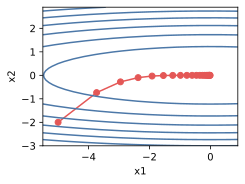

In [6]:
# RMSProp Optimization Trace

rmsprop_results = train_2d(
    rmsprop_2d,
    objective_gradient_2d,
)

show_trace_2d(
    objective_2d,
    rmsprop_results,
)